# Hospital Length of Stay (LOS) Prediction - Machine Learning Project

**Project Overview:**
This notebook presents a comprehensive machine learning pipeline to predict hospital length of stay (LOS) using patient encounter records. The project encompasses data preprocessing, feature engineering, multiple model training approaches, and thorough evaluation using both regression and classification metrics.

**Dataset:** Hospital_Patient_Records.xlsx
- 47,701 encounter records
- 793 unique patients
- Time period: 2011-2022

**Objective:** Predict the duration of hospital encounters to optimize resource allocation and improve patient care planning.

---
## 1. Introduction & Data Loading

We begin by importing necessary libraries and loading the hospital patient records dataset.

In [49]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import joblib


# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, recall_score, f1_score, classification_report, confusion_matrix
)

# XGBoost for gradient boosting
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost not available, will use alternative")
    XGBOOST_AVAILABLE = False

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")

Libraries imported successfully!
XGBoost available: True


In [4]:
# Load the dataset
df = pd.read_excel('sample_data/Hospital_Patient_Records.xlsx')

print("Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
print(f"Total Records: {len(df):,}")
print(f"Unique Patients: {df['PATIENT'].nunique():,}")
print(f"Unique Encounters: {df['ENCOUNTER'].nunique():,}")
print(f"Date Range: {df['START'].min()} to {df['STOP'].max()}")

Dataset loaded successfully!

Dataset Shape: (47701, 9)
Total Records: 47,701
Unique Patients: 793
Unique Encounters: 14,670
Date Range: 2011-01-02 10:26:36 to 2022-01-29 22:08:12


In [5]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2011-01-02 10:26:36,2011-01-02 13:58:36,3de74169-7f67-9304-91d4-757e0f3a14d2,32c84703-2481-49cd-d571-3899d5820253,265764009,Renal dialysis (procedure),903,NaN,NaN
1,2011-01-03 06:44:39,2011-01-03 07:01:42,d9ec2e44-32e9-9148-179a-1653348cc4e2,c98059da-320a-c0a6-fced-c8815f3e3f39,76601001,Intramuscular injection,2477,NaN,NaN
2,2011-01-04 15:49:55,2011-01-04 16:04:55,d856d6e6-4c98-e7a2-129b-44076c63d008,2cfd4ddd-ad13-fe1e-528b-15051cea2ec3,703423002,Combined chemotherapy and radiation therapy (p...,11620,363406005.0,Malignant tumor of colon
3,2011-01-05 05:02:09,2011-01-05 05:17:09,bc9d59c3-0a30-6e3b-f47d-022e4f03c8de,17966936-0878-f4db-128b-a43ae10d0878,173160006,Diagnostic fiberoptic bronchoscopy (procedure),9796,162573006.0,Suspected lung cancer (situation)
4,2011-01-05 13:58:36,2011-01-05 17:42:36,3de74169-7f67-9304-91d4-757e0f3a14d2,9de5f0b0-4ba4-ce6f-45fb-b55c202f31a5,265764009,Renal dialysis (procedure),1255,NaN,NaN


In [6]:
# Dataset information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47701 entries, 0 to 47700
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   START              47701 non-null  datetime64[ns]
 1   STOP               47701 non-null  datetime64[ns]
 2   PATIENT            47701 non-null  object        
 3   ENCOUNTER          47701 non-null  object        
 4   CODE               47701 non-null  int64         
 5   DESCRIPTION        47701 non-null  object        
 6   BASE_COST          47701 non-null  int64         
 7   REASONCODE         10756 non-null  float64       
 8   REASONDESCRIPTION  10756 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(2), object(4)
memory usage: 3.3+ MB


In [7]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,START,STOP,CODE,BASE_COST,REASONCODE
count,47701,47701,4.770100e+04,47701.000000,1.075600e+04
mean,2016-09-21 11:33:28.747510528,2016-09-21 12:06:44.542609152,1.098683e+14,2212.064967,3.342532e+11
min,2011-01-02 10:26:36,2011-01-02 13:58:36,1.225002e+06,1.000000,5.602001e+06
25%,2014-02-21 15:21:19,2014-02-21 16:08:51,2.251580e+08,431.000000,7.289200e+07
50%,2016-07-20 18:58:48,2016-07-20 19:13:48,4.153000e+08,431.000000,7.289200e+07
75%,2019-04-30 13:20:27,2019-04-30 13:51:34,7.629930e+08,966.000000,7.289200e+07
max,2022-01-29 21:35:37,2022-01-29 22:08:12,1.633503e+16,289531.000000,6.781100e+13
std,NaN,NaN,9.057080e+14,5572.978748,4.748533e+12


---
## 2. Data Preprocessing

In this section, we:
- Calculate the target variable (duration in hours)
- Handle missing values
- Identify and handle outliers
- Prepare data for feature engineering

In [8]:
# Create a copy for preprocessing
data = df.copy()

# Calculate target variable: duration in hours
data['duration_hours'] = (data['STOP'] - data['START']).dt.total_seconds() / 3600

print("Target Variable Created: duration_hours")
print(f"\nDuration Statistics:")
print(data['duration_hours'].describe())
print(f"\nMinimum duration: {data['duration_hours'].min():.2f} hours")
print(f"Maximum duration: {data['duration_hours'].max():.2f} hours")
print(f"Median duration: {data['duration_hours'].median():.2f} hours")

Target Variable Created: duration_hours

Duration Statistics:
count    47701.000000
mean         0.554388
std          1.923250
min          0.000000
25%          0.250000
50%          0.275556
75%          0.493056
max        384.000000
Name: duration_hours, dtype: float64

Minimum duration: 0.00 hours
Maximum duration: 384.00 hours
Median duration: 0.28 hours


Missing Values Analysis:
                              Column  Missing_Count  Missing_Percentage
REASONCODE                REASONCODE          36945               77.45
REASONDESCRIPTION  REASONDESCRIPTION          36945               77.45


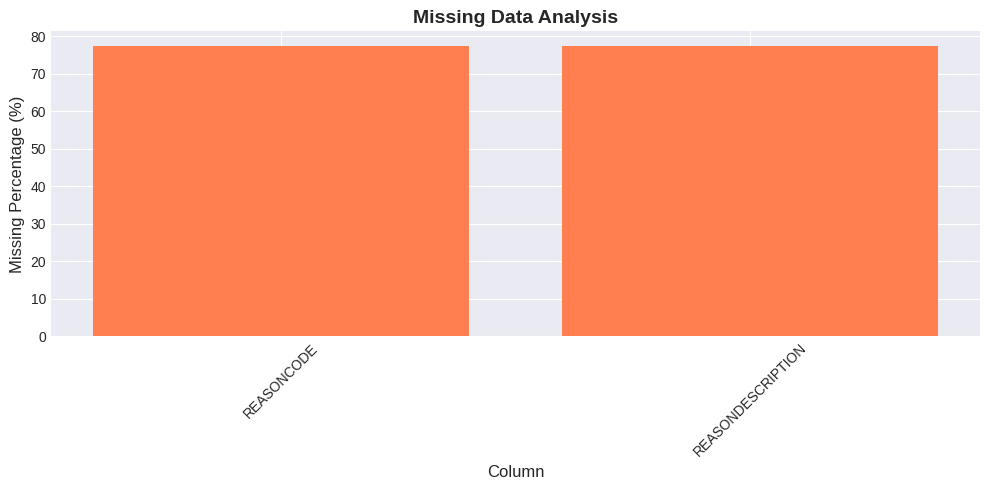

In [9]:
# Analyze missing values
print("Missing Values Analysis:")
missing_data = pd.DataFrame({
    'Column': data.columns,
    'Missing_Count': data.isnull().sum(),
    'Missing_Percentage': (data.isnull().sum() / len(data) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_data)

# Visualize missing data
plt.figure(figsize=(10, 5))
plt.bar(missing_data['Column'], missing_data['Missing_Percentage'], color='coral')
plt.xlabel('Column', fontsize=12)
plt.ylabel('Missing Percentage (%)', fontsize=12)
plt.title('Missing Data Analysis', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Handle missing values
# REASONCODE and REASONDESCRIPTION have ~77% missing - create a binary flag
data['has_reason'] = data['REASONDESCRIPTION'].notna().astype(int)

# Fill missing REASONDESCRIPTION with 'No Reason Specified'
data['REASONDESCRIPTION'] = data['REASONDESCRIPTION'].fillna('No Reason Specified')

# Fill missing REASONCODE with 0
data['REASONCODE'] = data['REASONCODE'].fillna(0)

print("Missing values handled successfully!")
print(f"\nRemaining missing values: {data.isnull().sum().sum()}")
print(f"Patients with specified reason: {data['has_reason'].sum()} ({data['has_reason'].mean()*100:.1f}%)")

Missing values handled successfully!

Remaining missing values: 0
Patients with specified reason: 10756 (22.5%)


Outliers detected: 5133 (10.76%)
Lower bound: -0.11 hours
Upper bound: 0.86 hours


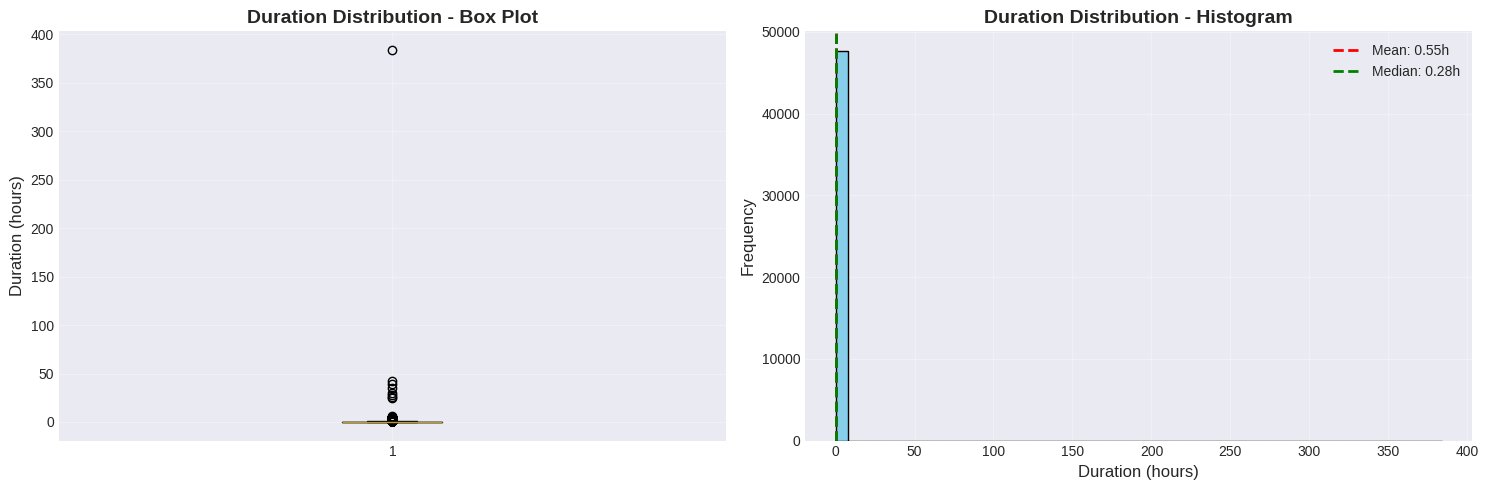

In [67]:
# Outlier detection for duration_hours
Q1 = data['duration_hours'].quantile(0.25)
Q3 = data['duration_hours'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['duration_hours'] < lower_bound) | (data['duration_hours'] > upper_bound)]
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
print(f"Lower bound: {lower_bound:.2f} hours")
print(f"Upper bound: {upper_bound:.2f} hours")

# Visualize duration distribution with outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
axes[0].boxplot(data['duration_hours'], vert=True)
axes[0].set_ylabel('Duration (hours)', fontsize=12)
axes[0].set_title('Duration Distribution - Box Plot', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Histogram
axes[1].hist(data['duration_hours'], bins=50, color='skyblue', edgecolor='black')
axes[1].axvline(data['duration_hours'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data["duration_hours"].mean():.2f}h')
axes[1].axvline(data['duration_hours'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {data["duration_hours"].median():.2f}h')
axes[1].set_xlabel('Duration (hours)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Duration Distribution - Histogram', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Handle outliers - cap extreme values instead of removing (to preserve data)
# We'll cap at the 99th percentile to handle extreme outliers
duration_99th = data['duration_hours'].quantile(0.99)
print(f"99th percentile duration: {duration_99th:.2f} hours")

# Create a flag for outliers before capping
data['is_outlier'] = ((data['duration_hours'] < lower_bound) |
                      (data['duration_hours'] > upper_bound)).astype(int)

# Cap extreme values
data['duration_hours_capped'] = data['duration_hours'].clip(upper=duration_99th)

print(f"\nDuration after capping:")
print(data['duration_hours_capped'].describe())

99th percentile duration: 3.67 hours

Duration after capping:
count    47701.000000
mean         0.540505
std          0.674257
min          0.000000
25%          0.250000
50%          0.275556
75%          0.493056
max          3.666667
Name: duration_hours_capped, dtype: float64


---
## 3. Feature Engineering

Creating comprehensive features for model training:
- Temporal features from START datetime
- Patient history features
- Encounter-specific features
- Cost-related features

In [13]:
# Sort by patient and start time for chronological processing
data = data.sort_values(['PATIENT', 'START']).reset_index(drop=True)

print("Data sorted chronologically by patient and start time")

Data sorted chronologically by patient and start time


In [14]:
# Temporal Features from START datetime
print("Creating temporal features...")

data['start_hour'] = data['START'].dt.hour
data['start_day_of_week'] = data['START'].dt.dayofweek  # Monday=0, Sunday=6
data['start_month'] = data['START'].dt.month
data['start_year'] = data['START'].dt.year
data['start_day'] = data['START'].dt.day

# Season (1=Winter, 2=Spring, 3=Summer, 4=Fall)
data['season'] = data['start_month'].map({
    12: 1, 1: 1, 2: 1,  # Winter
    3: 2, 4: 2, 5: 2,   # Spring
    6: 3, 7: 3, 8: 3,   # Summer
    9: 4, 10: 4, 11: 4  # Fall
})

# Is weekend flag
data['is_weekend'] = (data['start_day_of_week'] >= 5).astype(int)

# Time of day category (Morning, Afternoon, Evening, Night)
def get_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

data['time_of_day'] = data['start_hour'].apply(get_time_of_day)

print("Temporal features created successfully!")
print(f"Features: start_hour, start_day_of_week, start_month, start_year, season, is_weekend, time_of_day")

Creating temporal features...
Temporal features created successfully!
Features: start_hour, start_day_of_week, start_month, start_year, season, is_weekend, time_of_day


In [15]:
# Patient History Features
print("Creating patient history features...")

# Initialize columns
data['total_prior_encounters'] = 0
data['avg_prior_duration'] = 0.0
data['avg_prior_cost'] = 0.0
data['days_since_last_encounter'] = 0.0
data['encounters_last_30_days'] = 0
data['encounters_last_90_days'] = 0

# Group by patient for efficient processing
for patient_id in data['PATIENT'].unique():
    patient_mask = data['PATIENT'] == patient_id
    patient_data = data[patient_mask].copy()

    for idx in patient_data.index:
        current_start = data.loc[idx, 'START']

        # Get all prior encounters for this patient
        prior_encounters = patient_data[patient_data['START'] < current_start]

        if len(prior_encounters) > 0:
            # Total prior encounters
            data.loc[idx, 'total_prior_encounters'] = len(prior_encounters)

            # Average prior duration
            data.loc[idx, 'avg_prior_duration'] = prior_encounters['duration_hours'].mean()

            # Average prior cost
            data.loc[idx, 'avg_prior_cost'] = prior_encounters['BASE_COST'].mean()

            # Days since last encounter
            last_encounter_date = prior_encounters['START'].max()
            days_diff = (current_start - last_encounter_date).total_seconds() / (24 * 3600)
            data.loc[idx, 'days_since_last_encounter'] = days_diff

            # Encounters in last 30 days
            encounters_30d = prior_encounters[prior_encounters['START'] >= (current_start - timedelta(days=30))]
            data.loc[idx, 'encounters_last_30_days'] = len(encounters_30d)

            # Encounters in last 90 days
            encounters_90d = prior_encounters[prior_encounters['START'] >= (current_start - timedelta(days=90))]
            data.loc[idx, 'encounters_last_90_days'] = len(encounters_90d)

print("Patient history features created successfully!")
print(f"Features: total_prior_encounters, avg_prior_duration, avg_prior_cost, days_since_last_encounter")
print(f"          encounters_last_30_days, encounters_last_90_days")

Creating patient history features...
Patient history features created successfully!
Features: total_prior_encounters, avg_prior_duration, avg_prior_cost, days_since_last_encounter
          encounters_last_30_days, encounters_last_90_days


In [16]:
# Encode categorical variables
print("Encoding categorical features...")

# Label encode DESCRIPTION (procedure type)
le_description = LabelEncoder()
data['description_encoded'] = le_description.fit_transform(data['DESCRIPTION'])

# Label encode REASONDESCRIPTION (diagnosis)
le_reason = LabelEncoder()
data['reason_encoded'] = le_reason.fit_transform(data['REASONDESCRIPTION'])

# Label encode time_of_day
le_time = LabelEncoder()
data['time_of_day_encoded'] = le_time.fit_transform(data['time_of_day'])

print("Categorical encoding completed!")
print(f"Unique procedures (DESCRIPTION): {data['description_encoded'].nunique()}")
print(f"Unique diagnoses (REASONDESCRIPTION): {data['reason_encoded'].nunique()}")
print(f"Unique time periods: {data['time_of_day_encoded'].nunique()}")

Encoding categorical features...
Categorical encoding completed!
Unique procedures (DESCRIPTION): 163
Unique diagnoses (REASONDESCRIPTION): 47
Unique time periods: 4


In [17]:
# Create emergency flag based on procedure description
# Identify emergency-related keywords
emergency_keywords = ['emergency', 'urgent', 'acute', 'trauma', 'critical']
data['is_emergency'] = data['DESCRIPTION'].str.lower().str.contains(
    '|'.join(emergency_keywords), na=False
).astype(int)

print(f"Emergency encounters identified: {data['is_emergency'].sum()} ({data['is_emergency'].mean()*100:.2f}%)")

Emergency encounters identified: 3 (0.01%)


In [18]:
# Display summary of engineered features
print("\n" + "="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)

feature_summary = {
    'Temporal Features': ['start_hour', 'start_day_of_week', 'start_month', 'start_year',
                          'season', 'is_weekend', 'time_of_day_encoded'],
    'Patient History': ['total_prior_encounters', 'avg_prior_duration', 'avg_prior_cost',
                       'days_since_last_encounter', 'encounters_last_30_days', 'encounters_last_90_days'],
    'Encounter Features': ['description_encoded', 'reason_encoded', 'CODE'],
    'Cost Features': ['BASE_COST'],
    'Binary Flags': ['has_reason', 'is_emergency', 'is_outlier']
}

total_features = 0
for category, features in feature_summary.items():
    print(f"\n{category}: {len(features)} features")
    print(f"  - {', '.join(features)}")
    total_features += len(features)

print(f"\nTotal engineered features: {total_features}")
print("="*80)


FEATURE ENGINEERING SUMMARY

Temporal Features: 7 features
  - start_hour, start_day_of_week, start_month, start_year, season, is_weekend, time_of_day_encoded

Patient History: 6 features
  - total_prior_encounters, avg_prior_duration, avg_prior_cost, days_since_last_encounter, encounters_last_30_days, encounters_last_90_days

Encounter Features: 3 features
  - description_encoded, reason_encoded, CODE

Cost Features: 1 features
  - BASE_COST

Binary Flags: 3 features
  - has_reason, is_emergency, is_outlier

Total engineered features: 20


---
## 4. Exploratory Data Analysis

Visualizing patterns and relationships in the data to gain insights.

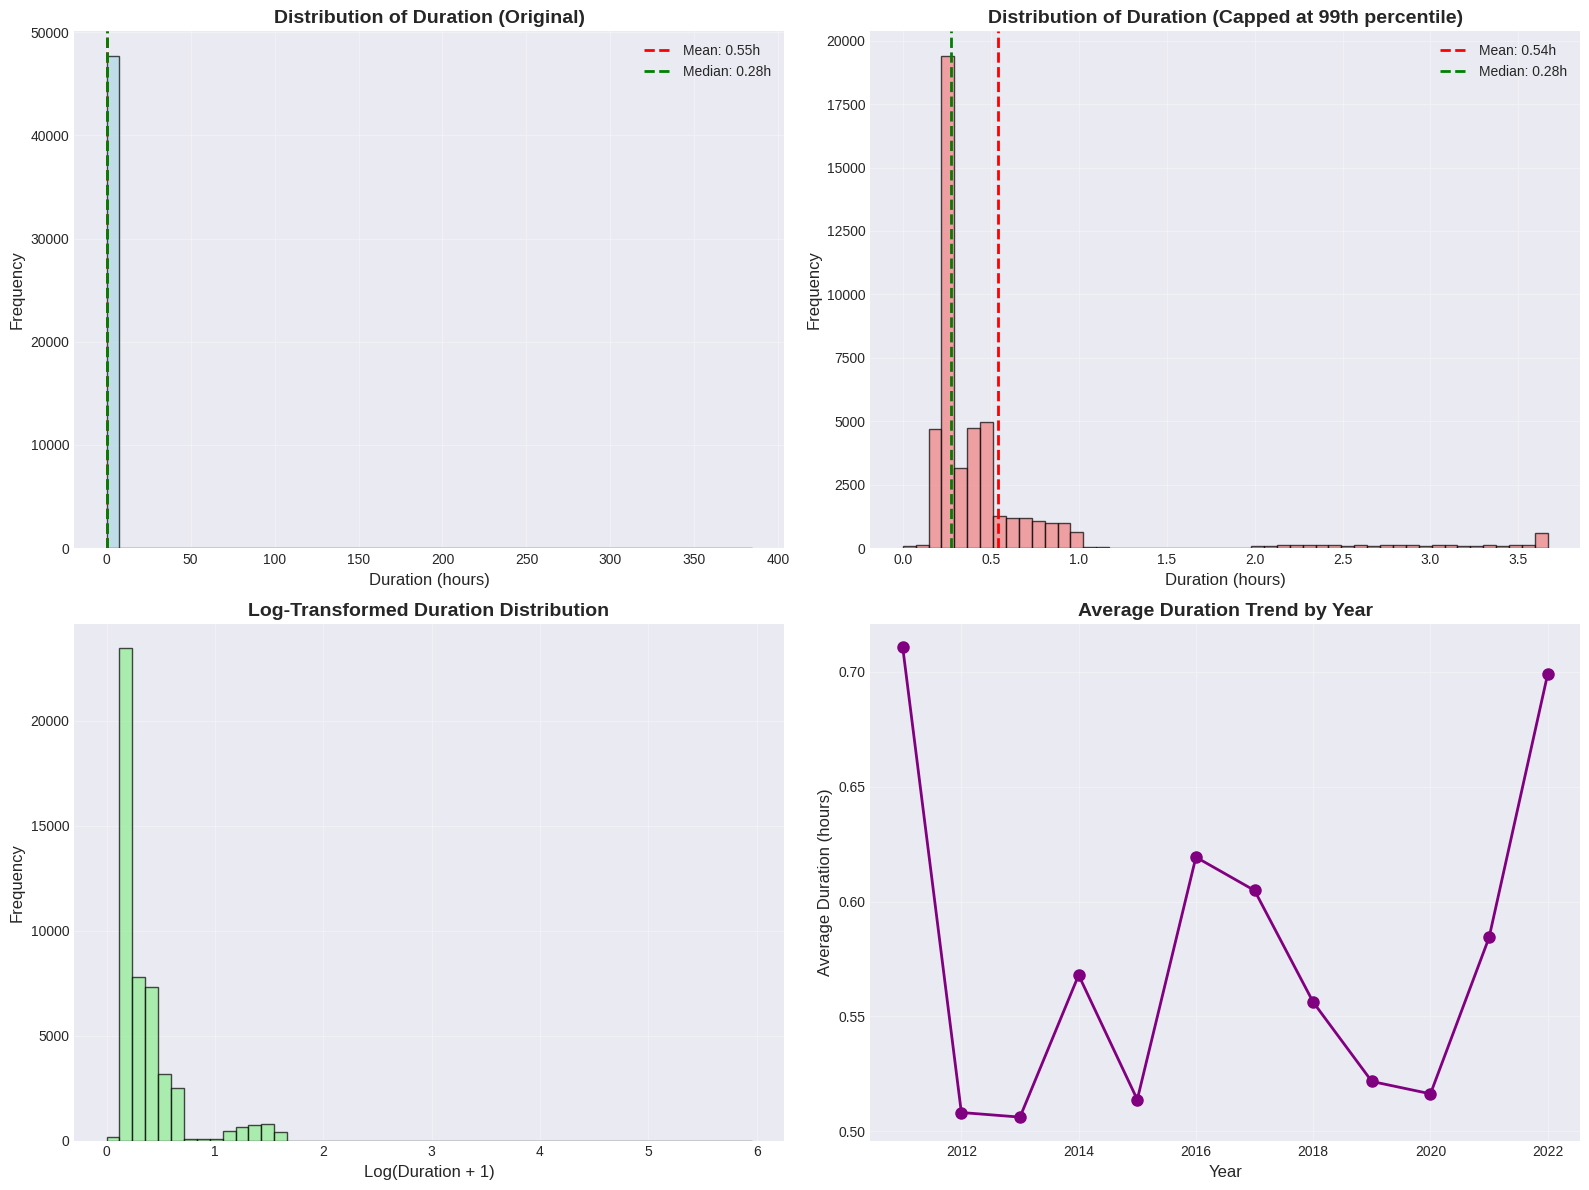

In [19]:
# Distribution of target variable (duration)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original duration distribution
axes[0, 0].hist(data['duration_hours'], bins=50, color='lightblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(data['duration_hours'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data["duration_hours"].mean():.2f}h')
axes[0, 0].axvline(data['duration_hours'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {data["duration_hours"].median():.2f}h')
axes[0, 0].set_xlabel('Duration (hours)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Duration (Original)', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Capped duration distribution
axes[0, 1].hist(data['duration_hours_capped'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(data['duration_hours_capped'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data["duration_hours_capped"].mean():.2f}h')
axes[0, 1].axvline(data['duration_hours_capped'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {data["duration_hours_capped"].median():.2f}h')
axes[0, 1].set_xlabel('Duration (hours)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Distribution of Duration (Capped at 99th percentile)', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Log-transformed duration
axes[1, 0].hist(np.log1p(data['duration_hours']), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Log(Duration + 1)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Log-Transformed Duration Distribution', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Duration by year
yearly_duration = data.groupby('start_year')['duration_hours'].mean().reset_index()
axes[1, 1].plot(yearly_duration['start_year'], yearly_duration['duration_hours'], marker='o', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('Year', fontsize=12)
axes[1, 1].set_ylabel('Average Duration (hours)', fontsize=12)
axes[1, 1].set_title('Average Duration Trend by Year', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

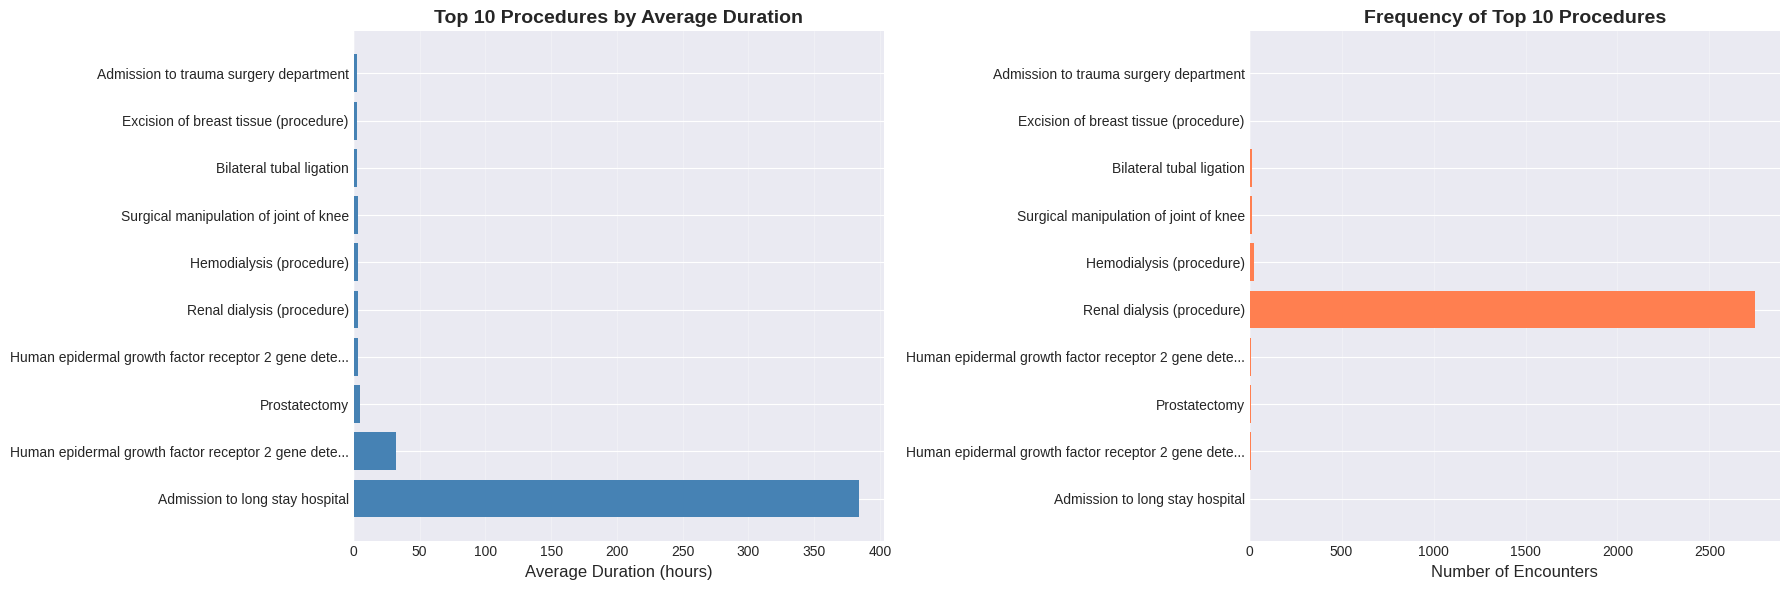

In [20]:
# Duration by procedure type (Top 10)
top_procedures = data.groupby('DESCRIPTION')['duration_hours'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Average duration
axes[0].barh(range(len(top_procedures)), top_procedures['mean'], color='steelblue')
axes[0].set_yticks(range(len(top_procedures)))
axes[0].set_yticklabels([desc[:50] + '...' if len(desc) > 50 else desc for desc in top_procedures.index], fontsize=10)
axes[0].set_xlabel('Average Duration (hours)', fontsize=12)
axes[0].set_title('Top 10 Procedures by Average Duration', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Count
axes[1].barh(range(len(top_procedures)), top_procedures['count'], color='coral')
axes[1].set_yticks(range(len(top_procedures)))
axes[1].set_yticklabels([desc[:50] + '...' if len(desc) > 50 else desc for desc in top_procedures.index], fontsize=10)
axes[1].set_xlabel('Number of Encounters', fontsize=12)
axes[1].set_title('Frequency of Top 10 Procedures', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

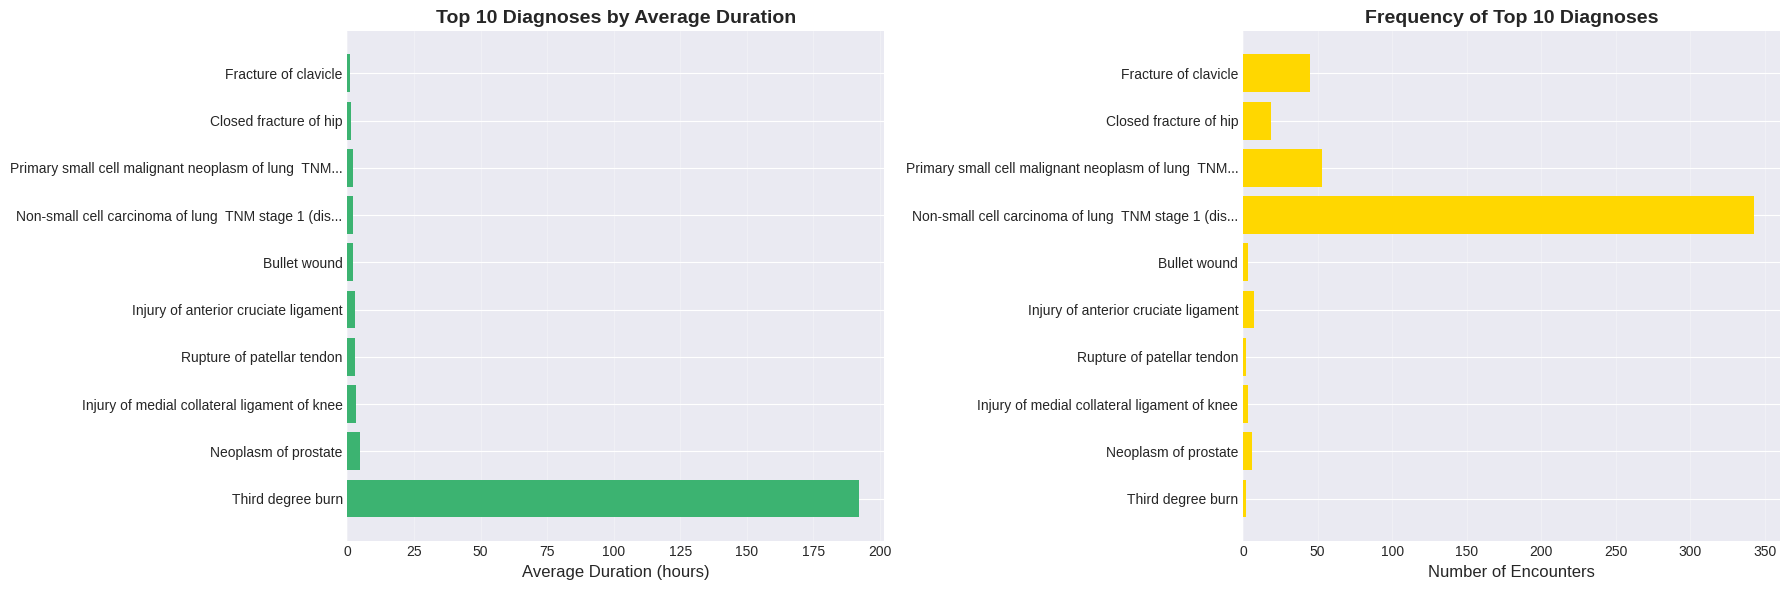

In [21]:
# Duration by diagnosis (Top 10 - excluding 'No Reason Specified')
top_diagnoses = data[data['REASONDESCRIPTION'] != 'No Reason Specified'].groupby('REASONDESCRIPTION')['duration_hours'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Average duration
axes[0].barh(range(len(top_diagnoses)), top_diagnoses['mean'], color='mediumseagreen')
axes[0].set_yticks(range(len(top_diagnoses)))
axes[0].set_yticklabels([desc[:50] + '...' if len(desc) > 50 else desc for desc in top_diagnoses.index], fontsize=10)
axes[0].set_xlabel('Average Duration (hours)', fontsize=12)
axes[0].set_title('Top 10 Diagnoses by Average Duration', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Count
axes[1].barh(range(len(top_diagnoses)), top_diagnoses['count'], color='gold')
axes[1].set_yticks(range(len(top_diagnoses)))
axes[1].set_yticklabels([desc[:50] + '...' if len(desc) > 50 else desc for desc in top_diagnoses.index], fontsize=10)
axes[1].set_xlabel('Number of Encounters', fontsize=12)
axes[1].set_title('Frequency of Top 10 Diagnoses', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

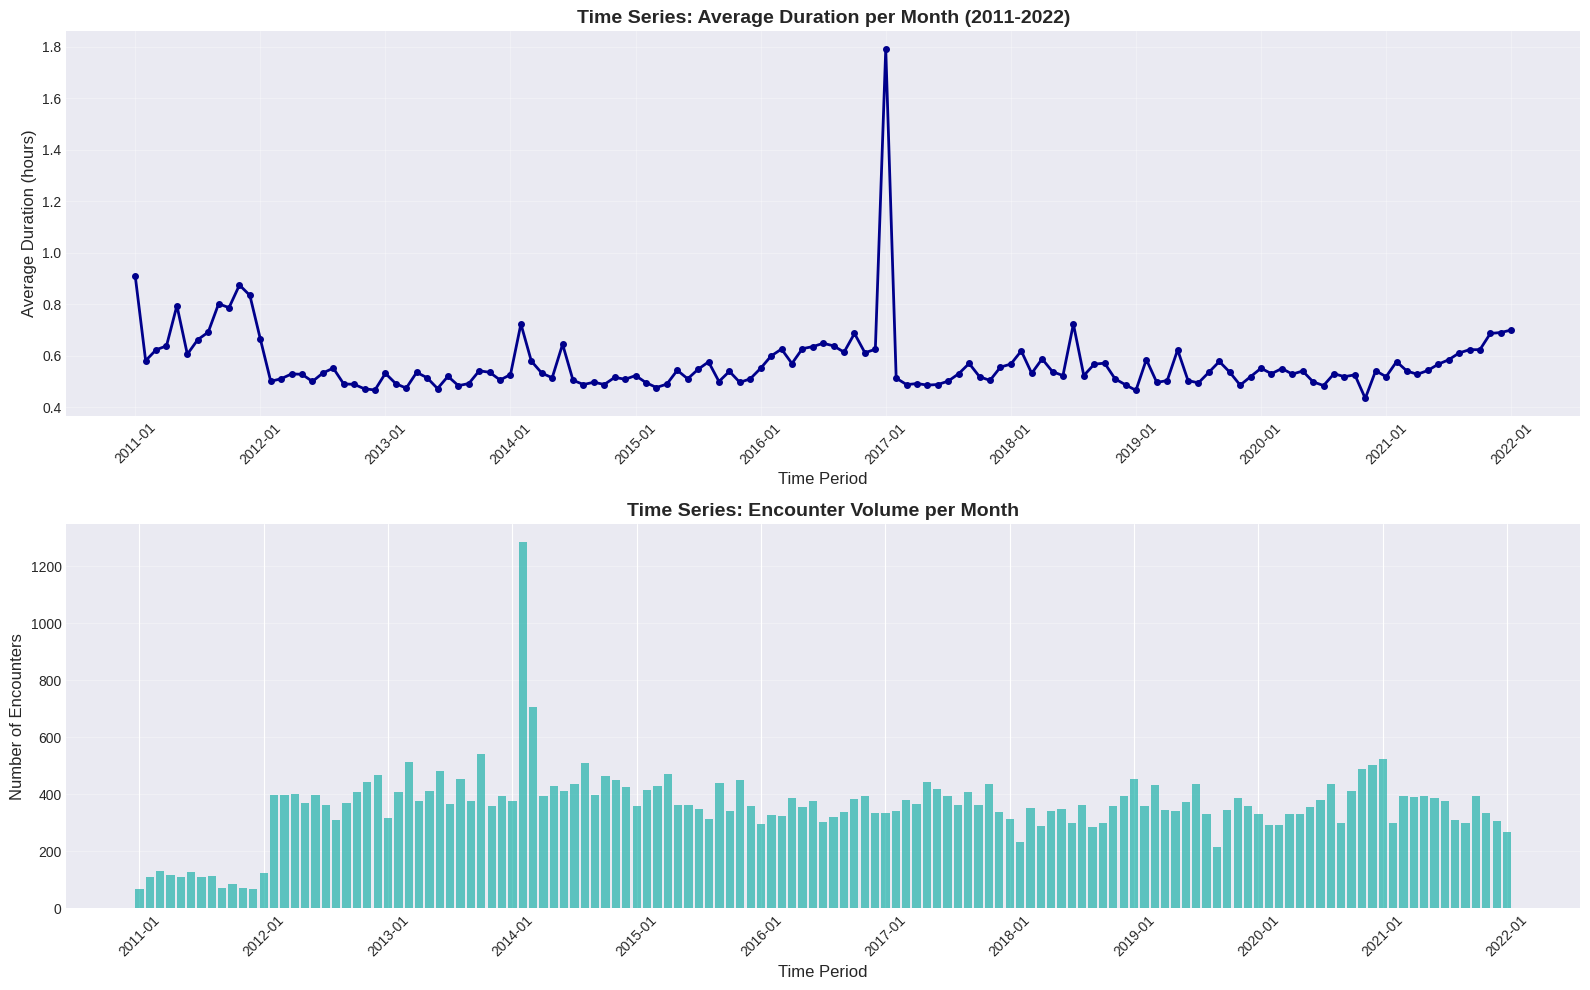

In [22]:
# Time series trend of average duration
data['year_month'] = data['START'].dt.to_period('M')
monthly_trend = data.groupby('year_month').agg({
    'duration_hours': 'mean',
    'ENCOUNTER': 'count'
}).reset_index()
monthly_trend['year_month'] = monthly_trend['year_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Average duration over time
axes[0].plot(range(len(monthly_trend)), monthly_trend['duration_hours'], linewidth=2, color='darkblue', marker='o', markersize=4)
axes[0].set_xlabel('Time Period', fontsize=12)
axes[0].set_ylabel('Average Duration (hours)', fontsize=12)
axes[0].set_title('Time Series: Average Duration per Month (2011-2022)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, len(monthly_trend), 12))
axes[0].set_xticklabels(monthly_trend['year_month'].iloc[::12], rotation=45)

# Encounter volume over time
axes[1].bar(range(len(monthly_trend)), monthly_trend['ENCOUNTER'], color='lightseagreen', alpha=0.7)
axes[1].set_xlabel('Time Period', fontsize=12)
axes[1].set_ylabel('Number of Encounters', fontsize=12)
axes[1].set_title('Time Series: Encounter Volume per Month', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(range(0, len(monthly_trend), 12))
axes[1].set_xticklabels(monthly_trend['year_month'].iloc[::12], rotation=45)

plt.tight_layout()
plt.show()

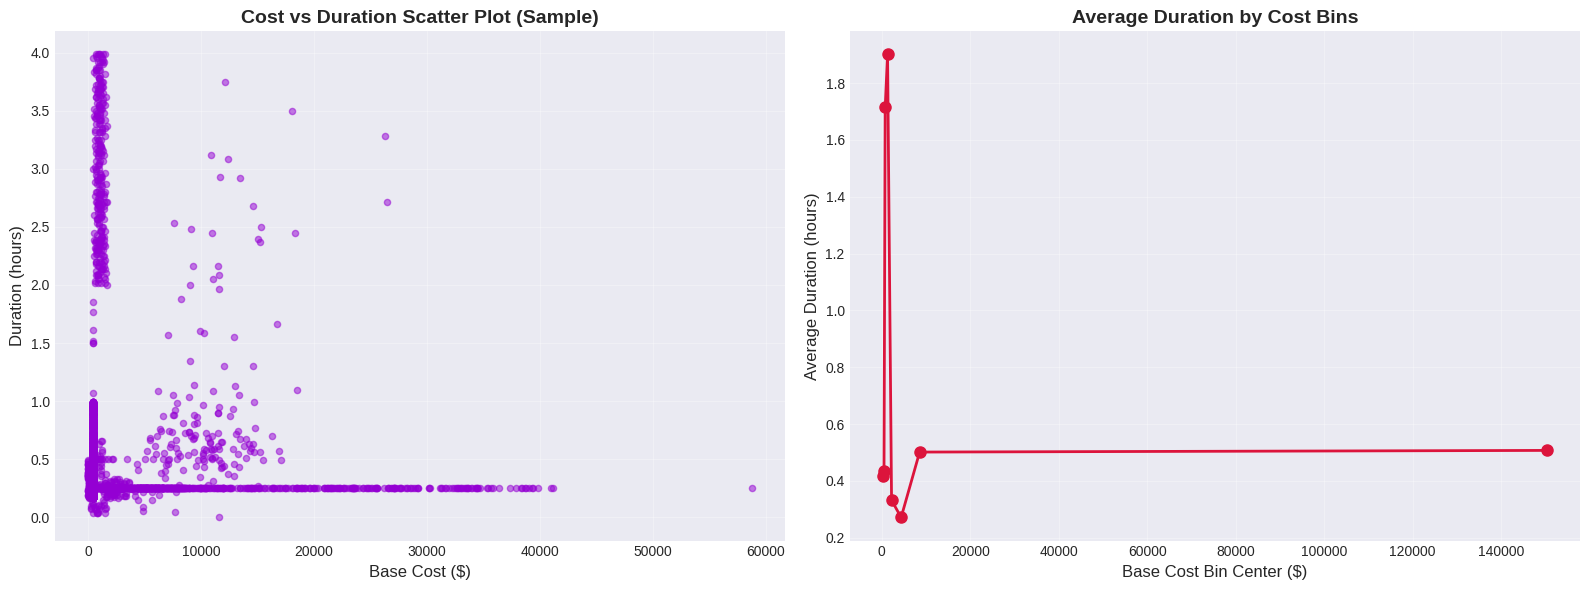

Correlation between BASE_COST and duration_hours: -0.0118


In [23]:
# Cost vs Duration relationship
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
sample_data = data.sample(n=min(5000, len(data)), random_state=42)  # Sample for visualization
axes[0].scatter(sample_data['BASE_COST'], sample_data['duration_hours'], alpha=0.5, s=20, color='darkviolet')
axes[0].set_xlabel('Base Cost ($)', fontsize=12)
axes[0].set_ylabel('Duration (hours)', fontsize=12)
axes[0].set_title('Cost vs Duration Scatter Plot (Sample)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Binned average
cost_bins = pd.qcut(data['BASE_COST'], q=20, duplicates='drop')
cost_duration_binned = data.groupby(cost_bins)['duration_hours'].mean()
bin_centers = [interval.mid for interval in cost_duration_binned.index]
axes[1].plot(bin_centers, cost_duration_binned.values, marker='o', linewidth=2, markersize=8, color='crimson')
axes[1].set_xlabel('Base Cost Bin Center ($)', fontsize=12)
axes[1].set_ylabel('Average Duration (hours)', fontsize=12)
axes[1].set_title('Average Duration by Cost Bins', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Correlation between BASE_COST and duration_hours: {data['BASE_COST'].corr(data['duration_hours']):.4f}")

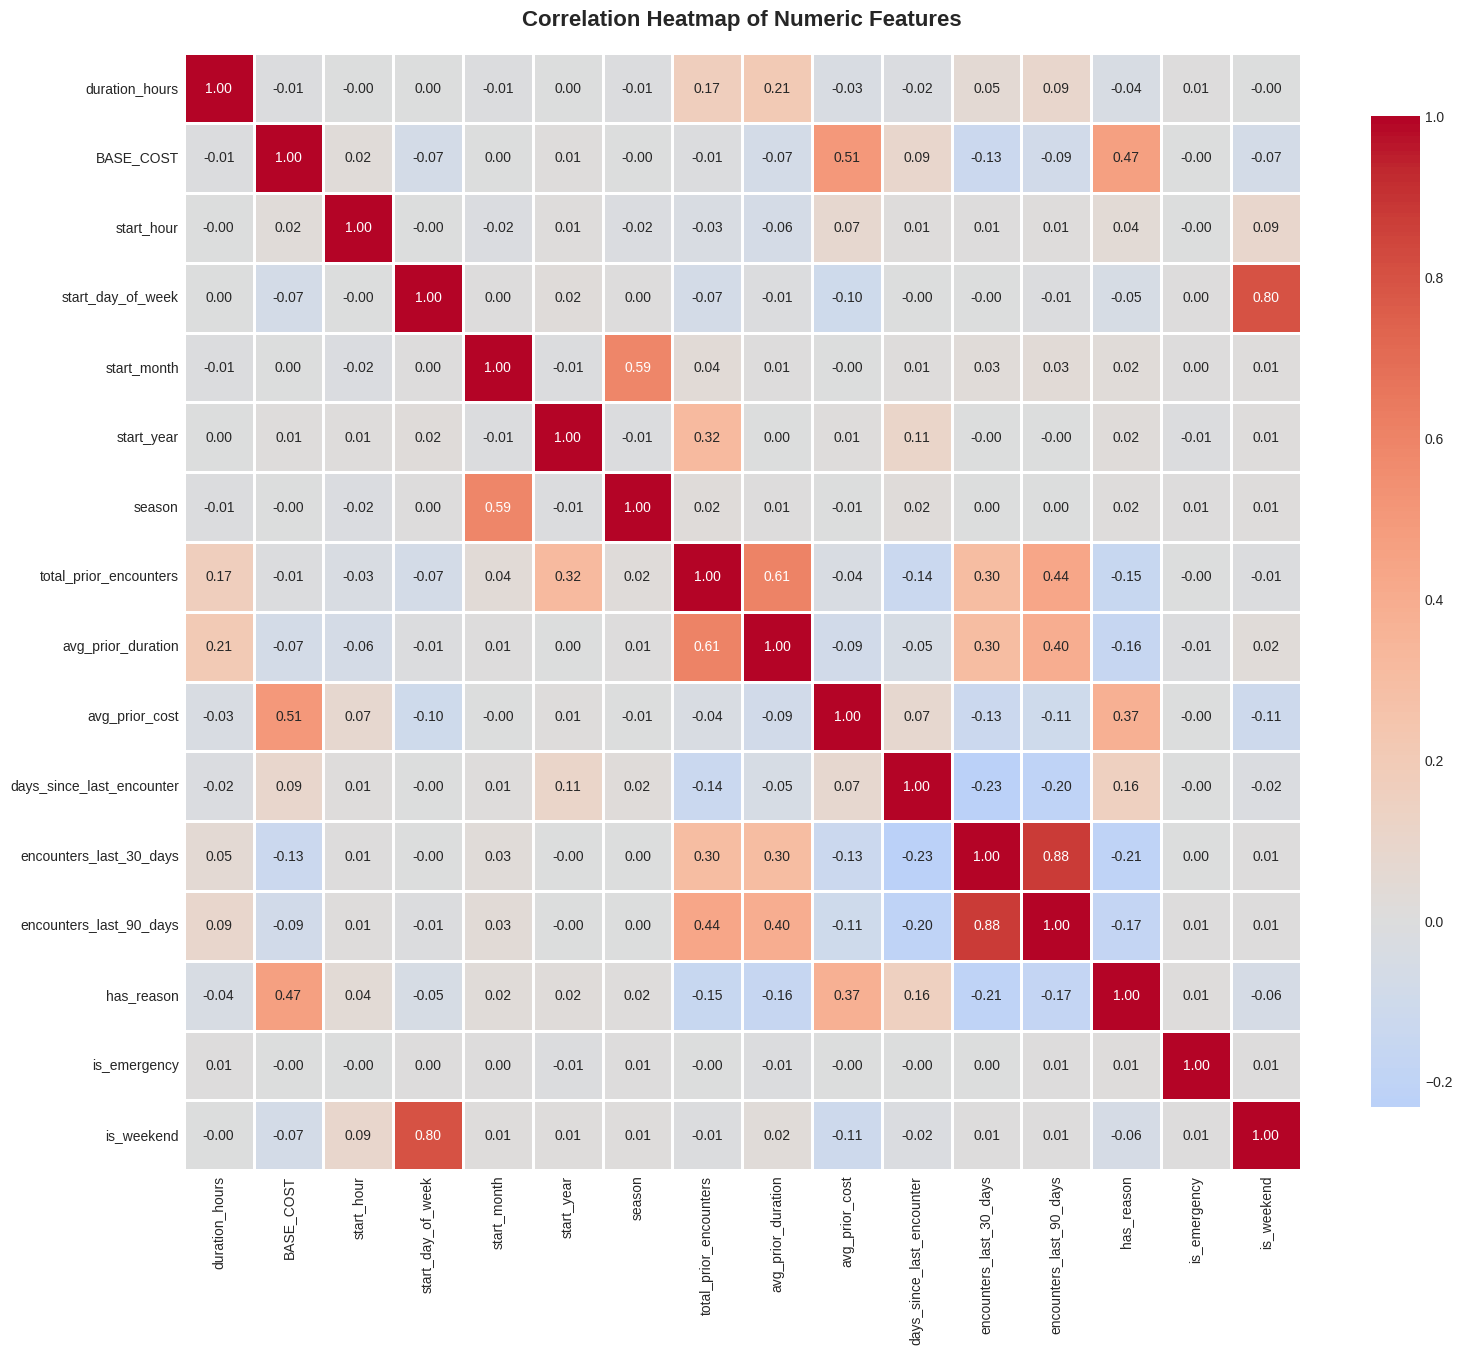


Top 10 Features Correlated with Duration:
avg_prior_duration         0.210426
total_prior_encounters     0.171854
encounters_last_90_days    0.092449
encounters_last_30_days    0.050974
is_emergency               0.006992
start_year                 0.002456
start_day_of_week          0.000742
start_hour                -0.004460
is_weekend                -0.004663
season                    -0.009371
Name: duration_hours, dtype: float64


In [24]:
# Correlation heatmap for numeric features
numeric_features = [
    'duration_hours', 'BASE_COST', 'start_hour', 'start_day_of_week', 'start_month',
    'start_year', 'season', 'total_prior_encounters', 'avg_prior_duration', 'avg_prior_cost',
    'days_since_last_encounter', 'encounters_last_30_days', 'encounters_last_90_days',
    'has_reason', 'is_emergency', 'is_weekend'
]

correlation_matrix = data[numeric_features].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numeric Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Top correlations with target variable
target_correlations = correlation_matrix['duration_hours'].sort_values(ascending=False)
print("\nTop 10 Features Correlated with Duration:")
print(target_correlations.head(11)[1:])  # Exclude duration_hours itself

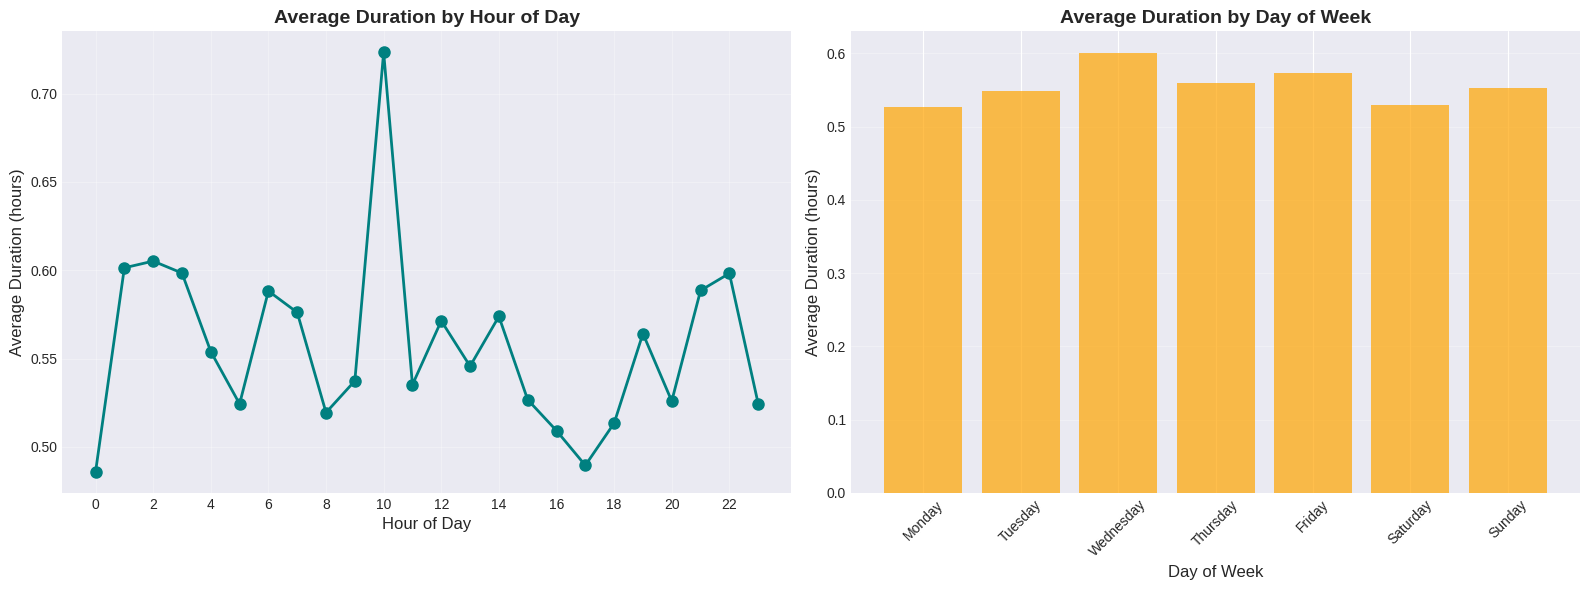

In [25]:
# Duration patterns by time of day and day of week
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By hour of day
hourly_duration = data.groupby('start_hour')['duration_hours'].mean()
axes[0].plot(hourly_duration.index, hourly_duration.values, marker='o', linewidth=2, markersize=8, color='teal')
axes[0].set_xlabel('Hour of Day', fontsize=12)
axes[0].set_ylabel('Average Duration (hours)', fontsize=12)
axes[0].set_title('Average Duration by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3)

# By day of week
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_duration = data.groupby('start_day_of_week')['duration_hours'].mean()
axes[1].bar(range(7), daily_duration.values, color='orange', alpha=0.7)
axes[1].set_xlabel('Day of Week', fontsize=12)
axes[1].set_ylabel('Average Duration (hours)', fontsize=12)
axes[1].set_title('Average Duration by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names, rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## 5. Model Training (Regression)

Preparing data and training multiple regression models to predict length of stay.

In [26]:
# Select features for modeling
feature_columns = [
    # Temporal features
    'start_hour', 'start_day_of_week', 'start_month', 'start_year', 'season', 'is_weekend',
    'time_of_day_encoded',
    # Patient history features
    'total_prior_encounters', 'avg_prior_duration', 'avg_prior_cost',
    'days_since_last_encounter', 'encounters_last_30_days', 'encounters_last_90_days',
    # Encounter features
    'description_encoded', 'reason_encoded', 'CODE',
    # Cost features
    'BASE_COST',
    # Binary flags
    'has_reason', 'is_emergency'
]

# Target variable - we'll use the capped version for better model performance
target_column = 'duration_hours_capped'

# Prepare feature matrix and target
X = data[feature_columns].copy()
y = data[target_column].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures used ({len(feature_columns)}):")
for i, feature in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {feature}")

Feature matrix shape: (47701, 19)
Target vector shape: (47701,)

Features used (19):
   1. start_hour
   2. start_day_of_week
   3. start_month
   4. start_year
   5. season
   6. is_weekend
   7. time_of_day_encoded
   8. total_prior_encounters
   9. avg_prior_duration
  10. avg_prior_cost
  11. days_since_last_encounter
  12. encounters_last_30_days
  13. encounters_last_90_days
  14. description_encoded
  15. reason_encoded
  16. CODE
  17. BASE_COST
  18. has_reason
  19. is_emergency


In [27]:
# Train-test split (80/20 with random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train-Test Split:")
print(f"  Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set:     {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTarget statistics:")
print(f"  Training mean: {y_train.mean():.2f} hours")
print(f"  Test mean:     {y_test.mean():.2f} hours")

Train-Test Split:
  Training set: 38,160 samples (80.0%)
  Test set:     9,541 samples (20.0%)

Target statistics:
  Training mean: 0.54 hours
  Test mean:     0.53 hours


In [28]:
# Scale features for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled for Linear Regression")

Features scaled for Linear Regression


### Model 1: Linear Regression (Baseline)

In [29]:
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print("✓ Linear Regression trained successfully!")

Training Linear Regression...
✓ Linear Regression trained successfully!


### Model 2: Random Forest Regressor

In [30]:
print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("✓ Random Forest trained successfully!")

Training Random Forest Regressor...
✓ Random Forest trained successfully!


### Model 3: Gradient Boosting (XGBoost)

In [31]:
if XGBOOST_AVAILABLE:
    print("Training XGBoost Regressor...")
    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)
    print("✓ XGBoost trained successfully!")
else:
    print("Using Gradient Boosting Regressor (scikit-learn) as alternative...")
    from sklearn.ensemble import GradientBoostingRegressor
    xgb_model = GradientBoostingRegressor(
        n_estimators=100,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)
    print("✓ Gradient Boosting trained successfully!")

Training XGBoost Regressor...
✓ XGBoost trained successfully!


---
## 6. Model Evaluation (Regression Metrics)

Evaluating model performance using R², MAE, RMSE, and MAPE metrics.

In [32]:
# Define evaluation function
def calculate_regression_metrics(y_true, y_pred, model_name):
    """Calculate comprehensive regression metrics"""
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE - handle zero values
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    return {
        'Model': model_name,
        'R² Score': r2,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape
    }

# Calculate metrics for all models
lr_metrics = calculate_regression_metrics(y_test, lr_pred, 'Linear Regression')
rf_metrics = calculate_regression_metrics(y_test, rf_pred, 'Random Forest')
xgb_metrics = calculate_regression_metrics(y_test, xgb_pred, 'Gradient Boosting')

# Create comparison dataframe
regression_results = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics])
regression_results = regression_results.round(4)

print("\n" + "="*80)
print("REGRESSION MODEL COMPARISON")
print("="*80)
print(regression_results.to_string(index=False))
print("="*80)


REGRESSION MODEL COMPARISON
            Model  R² Score    MAE   RMSE  MAPE (%)
Linear Regression    0.4355 0.2947 0.4903   74.8398
    Random Forest    0.9231 0.0746 0.1809   11.3730
Gradient Boosting    0.9186 0.0768 0.1862   11.8714


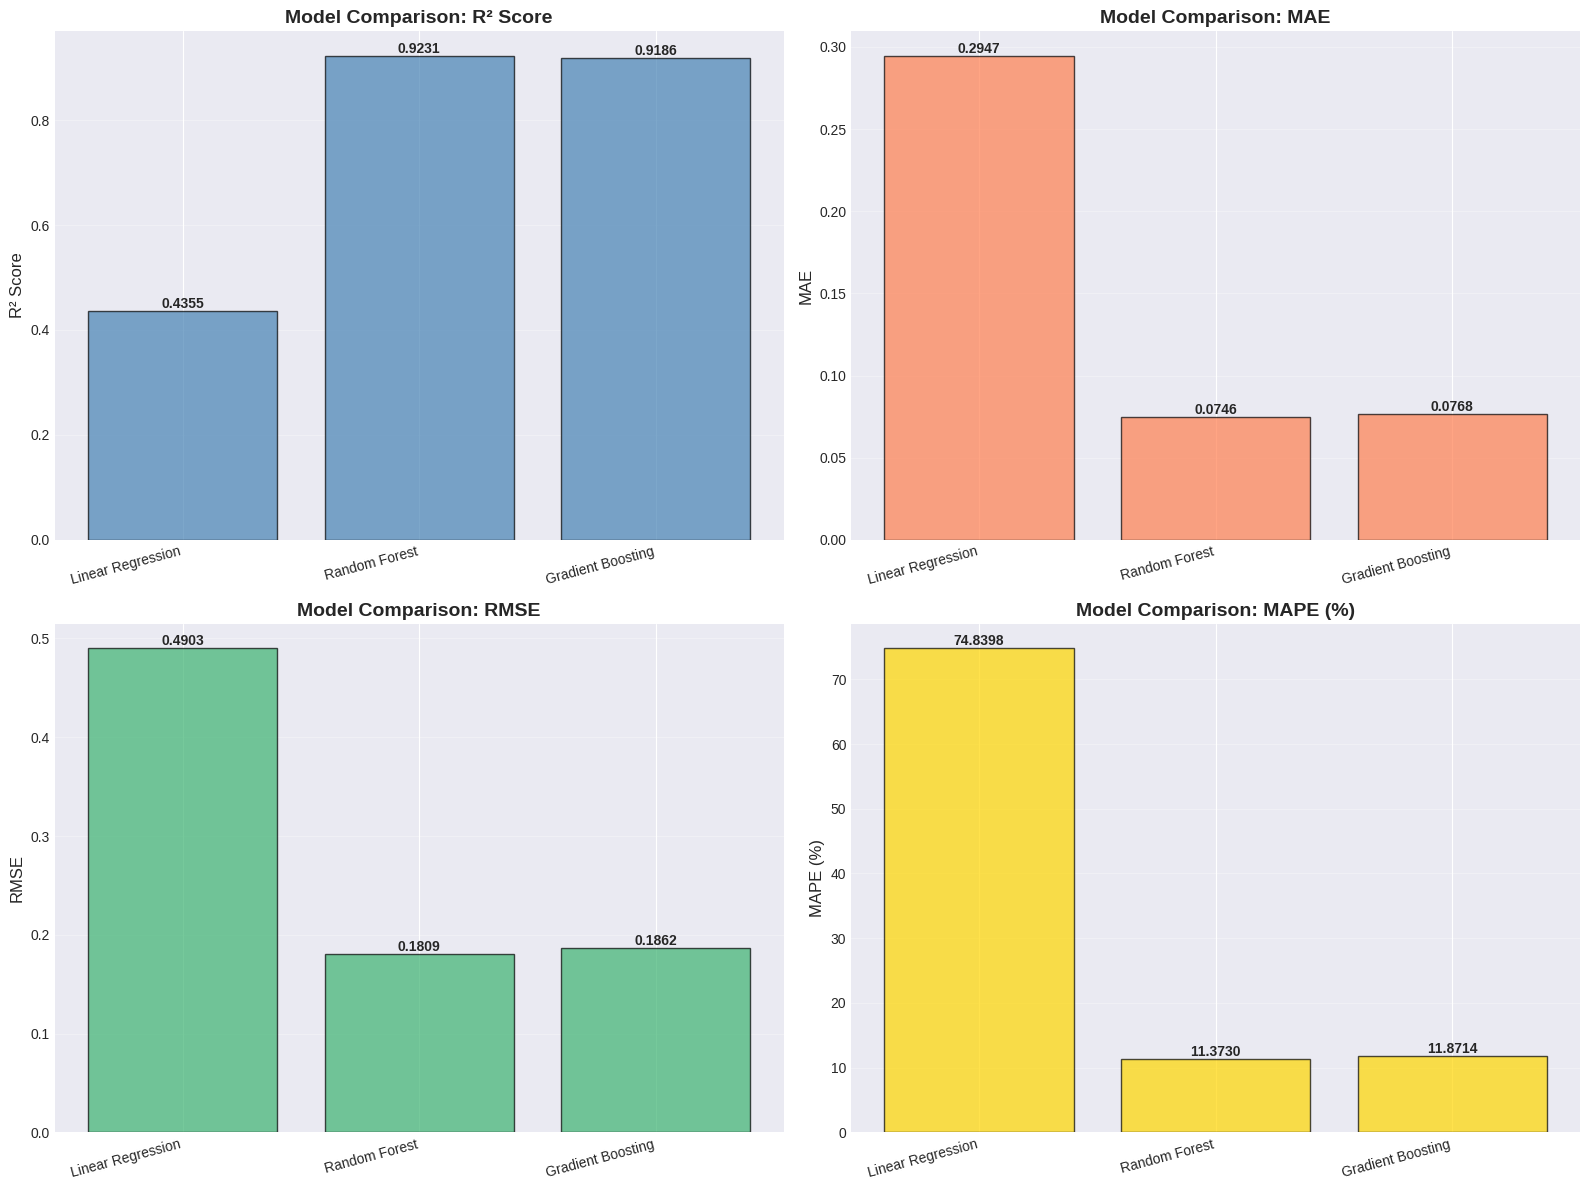

In [33]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['R² Score', 'MAE', 'RMSE', 'MAPE (%)']
colors = ['steelblue', 'coral', 'mediumseagreen', 'gold']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax = axes[idx // 2, idx % 2]
    values = regression_results[metric].values
    models = regression_results['Model'].values

    bars = ax.bar(models, values, color=color, alpha=0.7, edgecolor='black')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'Model Comparison: {metric}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xticklabels(models, rotation=15, ha='right')

plt.tight_layout()
plt.show()

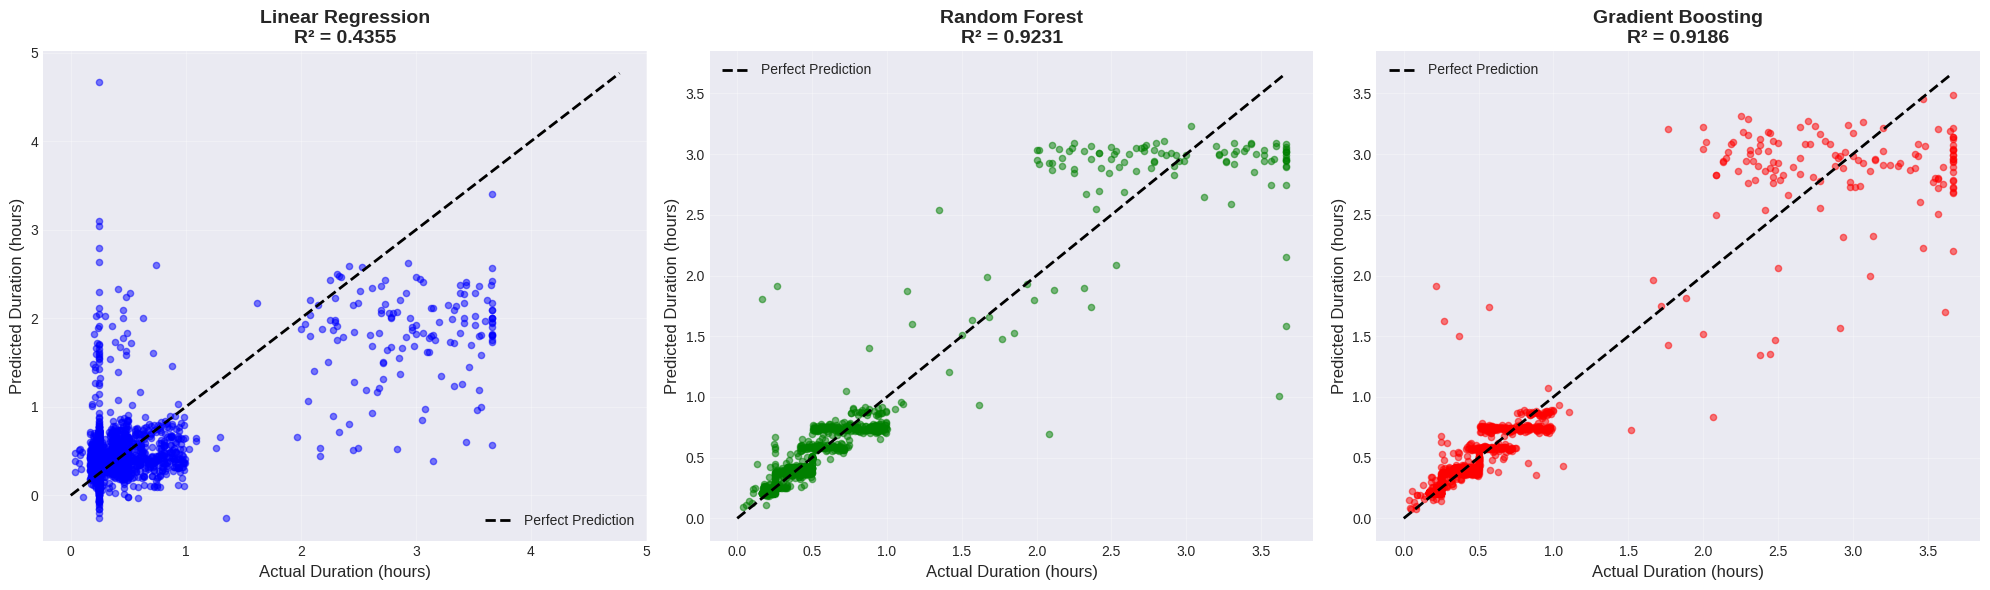

In [34]:
# Actual vs Predicted plots for all models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models_pred = [
    ('Linear Regression', lr_pred, 'blue'),
    ('Random Forest', rf_pred, 'green'),
    ('Gradient Boosting', xgb_pred, 'red')
]

for idx, (model_name, predictions, color) in enumerate(models_pred):
    ax = axes[idx]

    # Sample for visualization
    sample_size = min(2000, len(y_test))
    sample_idx = np.random.choice(len(y_test), sample_size, replace=False)

    ax.scatter(y_test.iloc[sample_idx], predictions[sample_idx], alpha=0.5, s=20, color=color)

    # Perfect prediction line
    max_val = max(y_test.max(), predictions.max())
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=2, label='Perfect Prediction')

    ax.set_xlabel('Actual Duration (hours)', fontsize=12)
    ax.set_ylabel('Predicted Duration (hours)', fontsize=12)
    ax.set_title(f'{model_name}\nR² = {r2_score(y_test, predictions):.4f}',
                 fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

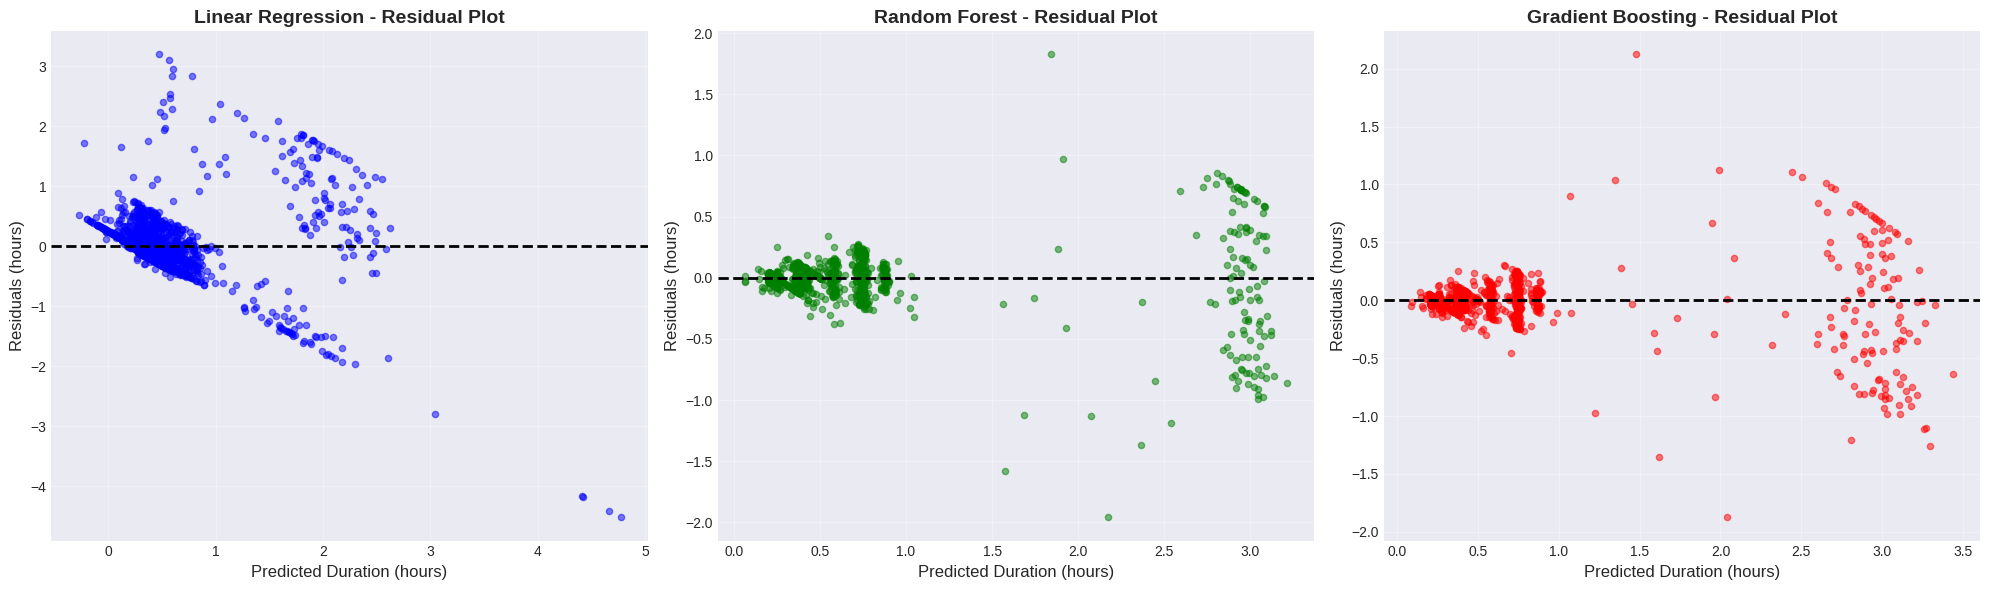

In [35]:
# Residual plots for all models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (model_name, predictions, color) in enumerate(models_pred):
    ax = axes[idx]

    residuals = y_test - predictions

    # Sample for visualization
    sample_size = min(2000, len(y_test))
    sample_idx = np.random.choice(len(y_test), sample_size, replace=False)

    ax.scatter(predictions[sample_idx], residuals.iloc[sample_idx], alpha=0.5, s=20, color=color)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=2)

    ax.set_xlabel('Predicted Duration (hours)', fontsize=12)
    ax.set_ylabel('Residuals (hours)', fontsize=12)
    ax.set_title(f'{model_name} - Residual Plot', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Feature Importance Analysis

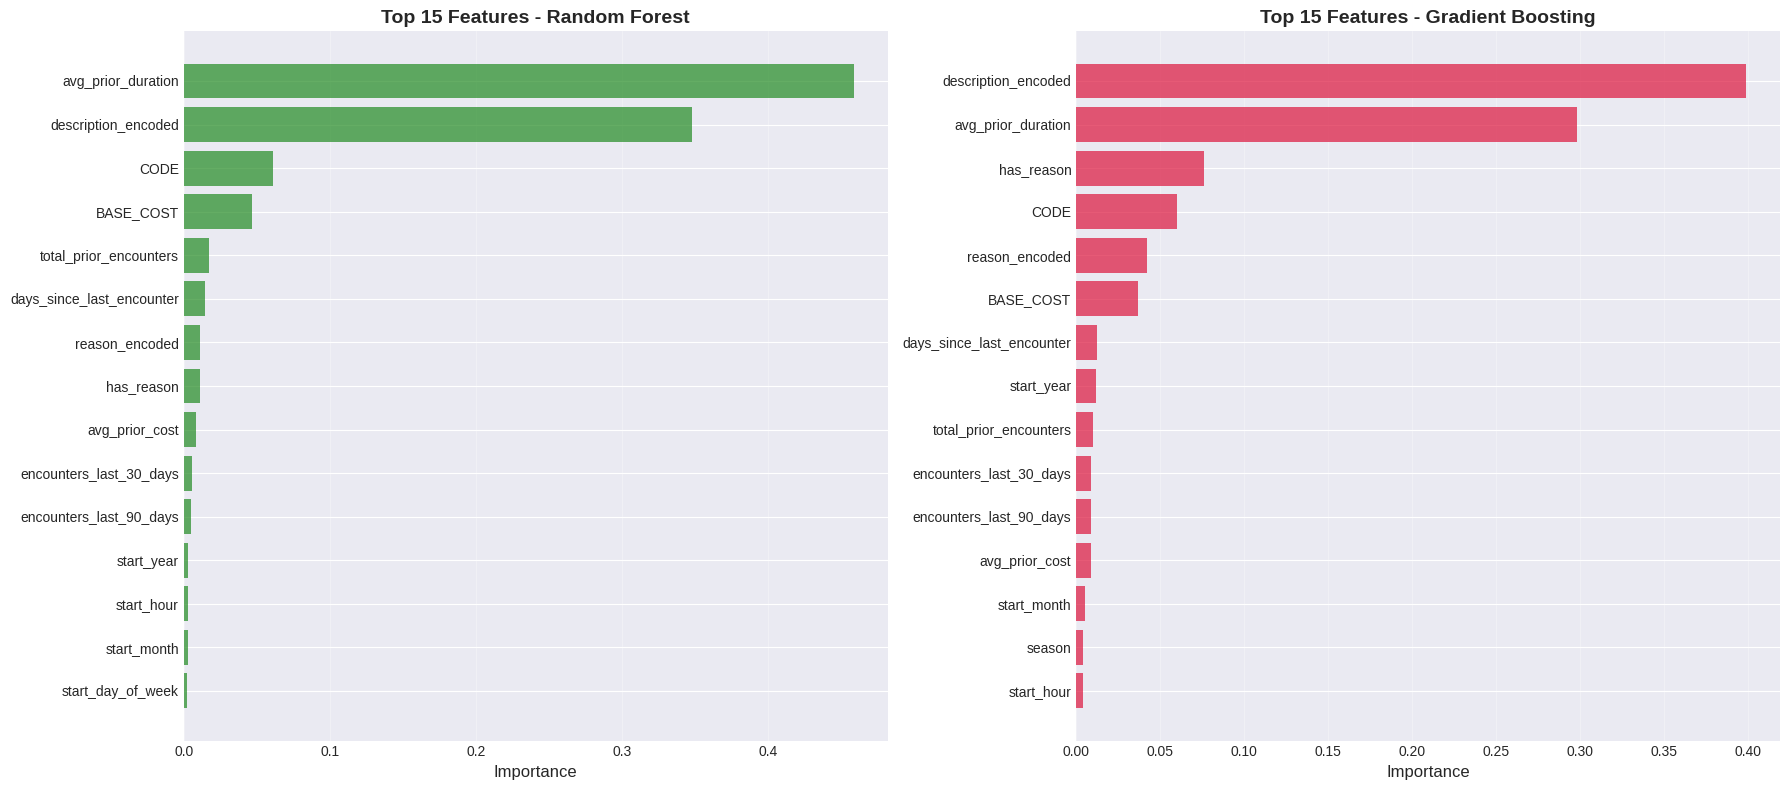


Top 10 Most Important Features (Random Forest):
                  Feature  Importance
       avg_prior_duration    0.458840
      description_encoded    0.348240
                     CODE    0.061240
                BASE_COST    0.046906
   total_prior_encounters    0.017369
days_since_last_encounter    0.014442
           reason_encoded    0.011105
               has_reason    0.011008
           avg_prior_cost    0.008131
  encounters_last_30_days    0.005680

Top 10 Most Important Features (Gradient Boosting):
                  Feature  Importance
      description_encoded    0.399275
       avg_prior_duration    0.298099
               has_reason    0.076075
                     CODE    0.060103
           reason_encoded    0.041977
                BASE_COST    0.036506
days_since_last_encounter    0.012379
               start_year    0.011512
   total_prior_encounters    0.010270
  encounters_last_30_days    0.008935


In [36]:
# Feature importance for Random Forest
rf_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Feature importance for Gradient Boosting
xgb_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualize top 15 features
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Random Forest
top_rf = rf_importance.head(15)
axes[0].barh(range(len(top_rf)), top_rf['Importance'], color='forestgreen', alpha=0.7)
axes[0].set_yticks(range(len(top_rf)))
axes[0].set_yticklabels(top_rf['Feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_title('Top 15 Features - Random Forest', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Gradient Boosting
top_xgb = xgb_importance.head(15)
axes[1].barh(range(len(top_xgb)), top_xgb['Importance'], color='crimson', alpha=0.7)
axes[1].set_yticks(range(len(top_xgb)))
axes[1].set_yticklabels(top_xgb['Feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('Top 15 Features - Gradient Boosting', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features (Random Forest):")
print(rf_importance.head(10).to_string(index=False))

print("\nTop 10 Most Important Features (Gradient Boosting):")
print(xgb_importance.head(10).to_string(index=False))

---
## 7. Classification Approach

Converting regression to classification for additional metrics (Accuracy, Recall, F1-Score).
We categorize duration into:
- SHORT: < 1 hour
- MEDIUM: 1-4 hours
- LONG: > 4 hours


Distribution of Duration Categories in Test Set:
duration_hours_capped
LONG       573
MEDIUM    1712
SHORT     7256
Name: count, dtype: int64

Percentages:
duration_hours_capped
LONG       6.01
MEDIUM    17.94
SHORT     76.05
Name: count, dtype: float64


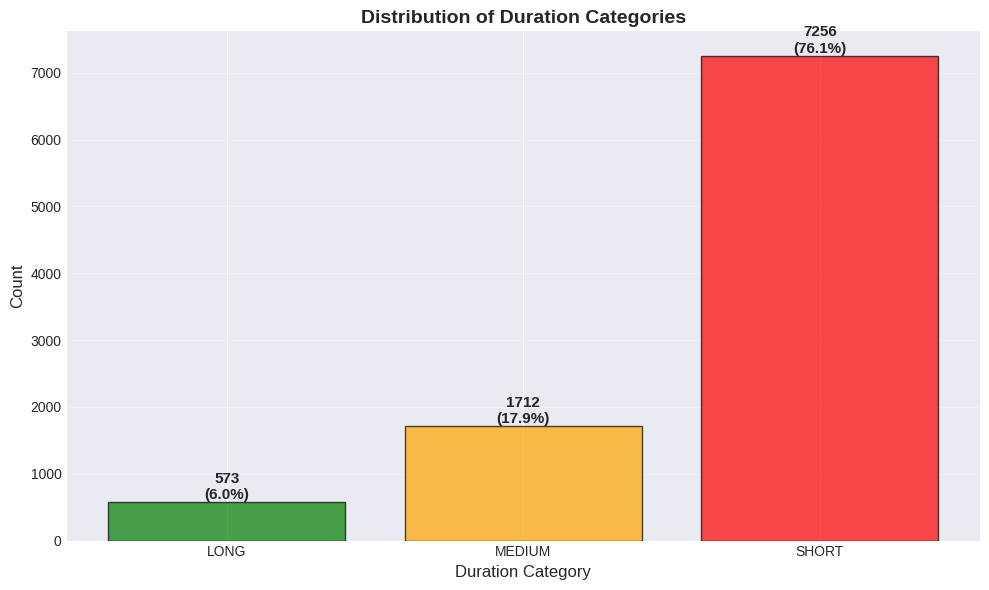

In [51]:
# Create duration categories
def categorize_duration(hours):
    if hours < 0.5:
        return 'SHORT'
    elif hours <= 2:
        return 'MEDIUM'
    else:
        return 'LONG'

# Apply to actual values
y_test_cat = y_test.apply(categorize_duration)

# Apply to predictions
lr_pred_cat = pd.Series(lr_pred).apply(categorize_duration)
rf_pred_cat = pd.Series(rf_pred).apply(categorize_duration)
xgb_pred_cat = pd.Series(xgb_pred).apply(categorize_duration)

# Distribution of categories
category_dist = y_test_cat.value_counts().sort_index()
print("\nDistribution of Duration Categories in Test Set:")
print(category_dist)
print(f"\nPercentages:")
print((category_dist / len(y_test_cat) * 100).round(2))

# Visualize distribution
plt.figure(figsize=(10, 6))
plt.bar(category_dist.index, category_dist.values, color=['green', 'orange', 'red'], alpha=0.7, edgecolor='black')
plt.xlabel('Duration Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Duration Categories', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (cat, count) in enumerate(category_dist.items()):
    plt.text(i, count, f'{count}\n({count/len(y_test_cat)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [53]:
# Calculate classification metrics
def calculate_classification_metrics(y_true, y_pred, model_name):
    """Calculate classification metrics"""
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Recall (Macro)': recall,
        'F1-Score (Macro)': f1
    }

# Calculate metrics for all models
lr_class_metrics = calculate_classification_metrics(y_test_cat, lr_pred_cat, 'Linear Regression')
rf_class_metrics = calculate_classification_metrics(y_test_cat, rf_pred_cat, 'Random Forest')
xgb_class_metrics = calculate_classification_metrics(y_test_cat, xgb_pred_cat, 'Gradient Boosting')

# Create comparison dataframe
classification_results = pd.DataFrame([lr_class_metrics, rf_class_metrics, xgb_class_metrics])
classification_results = classification_results.round(4)

print("\n" + "="*80)
print("CLASSIFICATION METRICS (Duration Categories)")
print("="*80)
print(classification_results.to_string(index=False))
print("="*80)


CLASSIFICATION METRICS (Duration Categories)
            Model  Accuracy  Recall (Macro)  F1-Score (Macro)
Linear Regression    0.6236          0.4960            0.5175
    Random Forest    0.9687          0.9537            0.9531
Gradient Boosting    0.9677          0.9517            0.9524


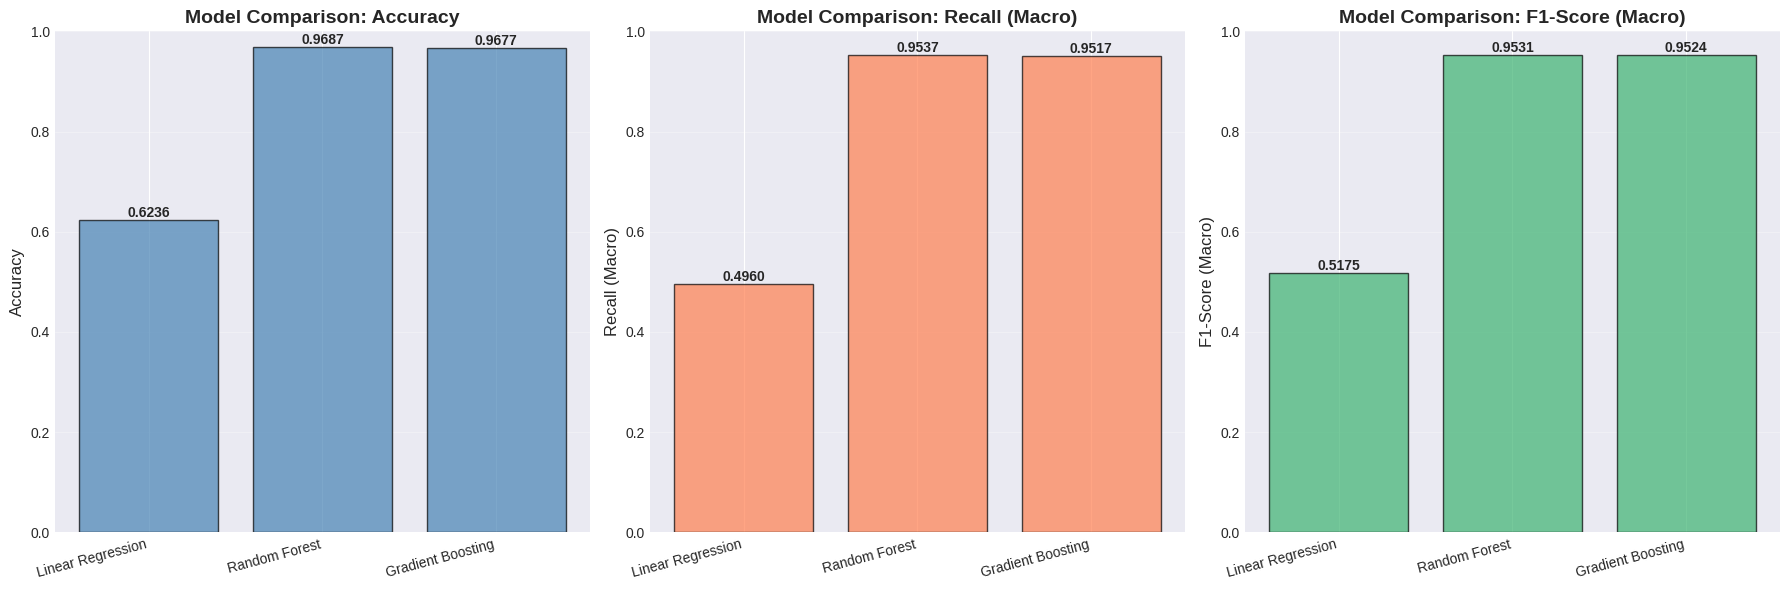

In [54]:
# Visualize classification metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_class = ['Accuracy', 'Recall (Macro)', 'F1-Score (Macro)']
colors_class = ['steelblue', 'coral', 'mediumseagreen']

for idx, (metric, color) in enumerate(zip(metrics_class, colors_class)):
    ax = axes[idx]
    values = classification_results[metric].values
    models = classification_results['Model'].values

    bars = ax.bar(models, values, color=color, alpha=0.7, edgecolor='black')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'Model Comparison: {metric}', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xticklabels(models, rotation=15, ha='right')

plt.tight_layout()
plt.show()

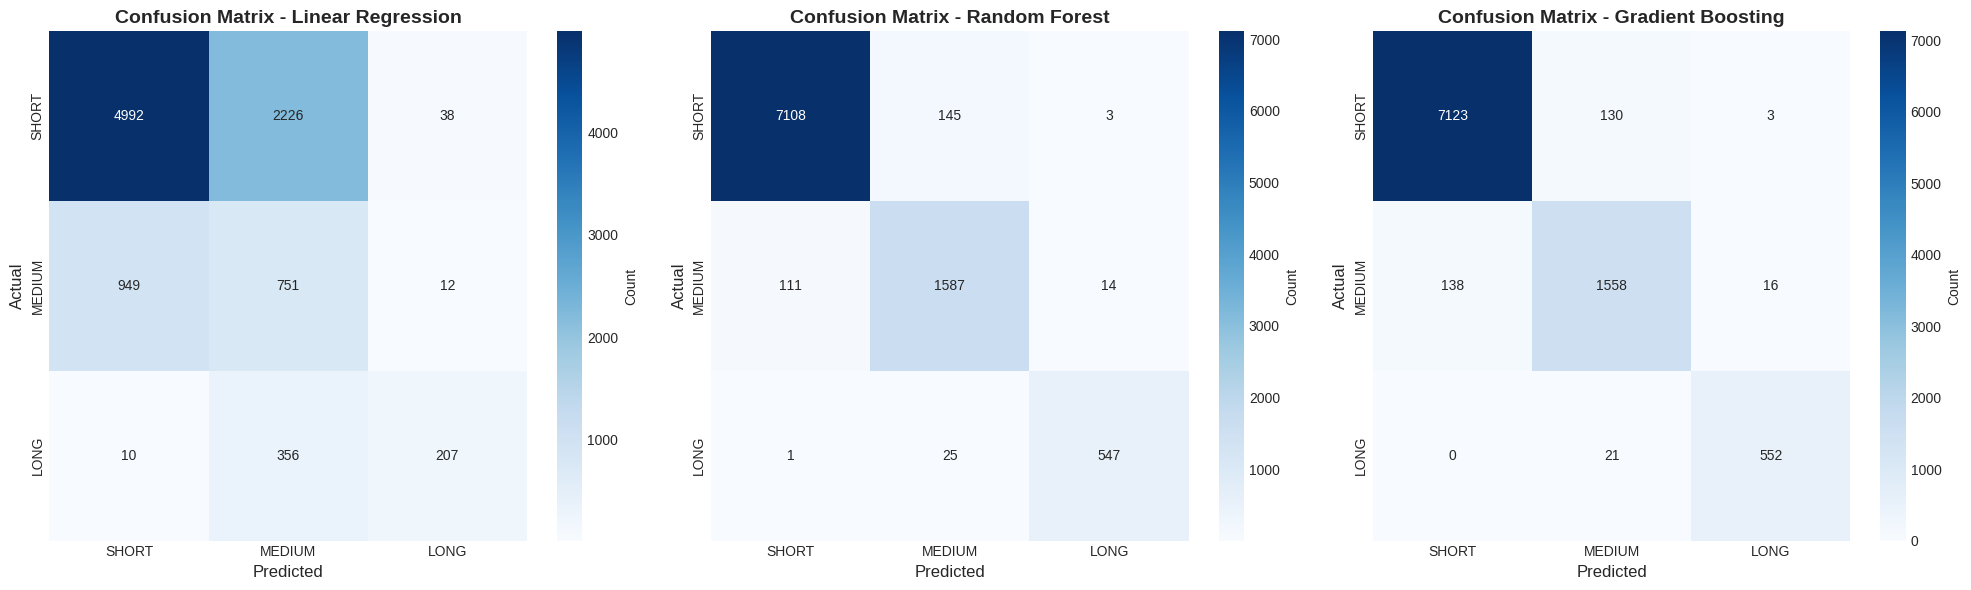

In [55]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models_class_pred = [
    ('Linear Regression', lr_pred_cat),
    ('Random Forest', rf_pred_cat),
    ('Gradient Boosting', xgb_pred_cat)
]

for idx, (model_name, predictions) in enumerate(models_class_pred):
    ax = axes[idx]

    cm = confusion_matrix(y_test_cat, predictions, labels=['SHORT', 'MEDIUM', 'LONG'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['SHORT', 'MEDIUM', 'LONG'],
                yticklabels=['SHORT', 'MEDIUM', 'LONG'],
                cbar_kws={'label': 'Count'})

    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [56]:
# Detailed classification reports
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORTS")
print("="*80)

for model_name, predictions in models_class_pred:
    print(f"\n{model_name}:")
    print("-" * 80)
    print(classification_report(y_test_cat, predictions, target_names=['SHORT', 'MEDIUM', 'LONG']))
    print("-" * 80)


DETAILED CLASSIFICATION REPORTS

Linear Regression:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

       SHORT       0.81      0.36      0.50       573
      MEDIUM       0.23      0.44      0.30      1712
        LONG       0.84      0.69      0.76      7256

    accuracy                           0.62      9541
   macro avg       0.62      0.50      0.52      9541
weighted avg       0.73      0.62      0.66      9541

--------------------------------------------------------------------------------

Random Forest:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

       SHORT       0.97      0.95      0.96       573
      MEDIUM       0.90      0.93      0.91      1712
        LONG       0.98      0.98      0.98      7256

    accuracy                           0.97      9541
   macro avg       0.95      0.95  

---
## 8. Results Comparison & Conclusions

Final analysis, model comparison, and business insights.

In [57]:
# Combined results table
combined_results = regression_results.merge(classification_results, on='Model')

print("\n" + "="*100)
print("COMPREHENSIVE MODEL COMPARISON - ALL METRICS")
print("="*100)
print(combined_results.to_string(index=False))
print("="*100)


COMPREHENSIVE MODEL COMPARISON - ALL METRICS
            Model  R² Score    MAE   RMSE  MAPE (%)  Accuracy  Recall (Macro)  F1-Score (Macro)
Linear Regression    0.4355 0.2947 0.4903   74.8398    0.6236          0.4960            0.5175
    Random Forest    0.9231 0.0746 0.1809   11.3730    0.9687          0.9537            0.9531
Gradient Boosting    0.9186 0.0768 0.1862   11.8714    0.9677          0.9517            0.9524


In [58]:
# Identify best models
best_r2 = combined_results.loc[combined_results['R² Score'].idxmax(), 'Model']
best_mae = combined_results.loc[combined_results['MAE'].idxmin(), 'Model']
best_accuracy = combined_results.loc[combined_results['Accuracy'].idxmax(), 'Model']
best_f1 = combined_results.loc[combined_results['F1-Score (Macro)'].idxmax(), 'Model']

print("\n" + "="*80)
print("BEST PERFORMING MODELS BY METRIC")
print("="*80)
print(f"Best R² Score:          {best_r2} ({combined_results.loc[combined_results['Model'] == best_r2, 'R² Score'].values[0]:.4f})")
print(f"Best MAE:               {best_mae} ({combined_results.loc[combined_results['Model'] == best_mae, 'MAE'].values[0]:.4f} hours)")
print(f"Best Accuracy:          {best_accuracy} ({combined_results.loc[combined_results['Model'] == best_accuracy, 'Accuracy'].values[0]:.4f})")
print(f"Best F1-Score (Macro):  {best_f1} ({combined_results.loc[combined_results['Model'] == best_f1, 'F1-Score (Macro)'].values[0]:.4f})")
print("="*80)


BEST PERFORMING MODELS BY METRIC
Best R² Score:          Random Forest (0.9231)
Best MAE:               Random Forest (0.0746 hours)
Best Accuracy:          Random Forest (0.9687)
Best F1-Score (Macro):  Random Forest (0.9531)


#Saving best model

In [60]:
joblib.dump(rf_model, 'best_los_model.joblib')
joblib.dump({'description': le_description, 'reason': le_reason, 'time_of_day': le_time}, 'encoders.joblib')

['encoders.joblib']